# Étude Approfondie : Données Socio-Économiques (INSEE)

## 1. Introduction et Objectifs
L'objectif de ce notebook est d'explorer le dataset des revenus de l'INSEE afin de sélectionner les indicateurs les plus pertinents pour expliquer l'adoption des véhicules électriques.

## 2. Chargement et Aperçu des données

In [1]:
import pandas as pd
from src.loading import load_revenu_data

url_revenus='https://www.data.gouv.fr/api/1/datasets/r/516130bc-4dcb-47f5-8347-ae96553c43ab'
df_revenus = load_revenu_data(url_revenus)

print(f"Le dataset contient {df_revenus.shape[0]} communes et {df_revenus.shape[1]} variables.")
df_revenus.sample(5)

Le dataset contient 34926 communes et 57 variables.


,Nom géographique GMS,Code géographique,Libellé géographique,[DISP] Nbre de ménages fiscaux,[DISP] Nbre de personnes dans les ménages fiscaux,[DISP] Nbre d'unités de consommation dans les ménages fiscaux,[DISP] 1ᵉʳ quartile (€),[DISP] Médiane (€),[DISP] 3ᵉ quartile (€),[DISP] Écart interquartile (€),...,[DEC] 9ᵉ décile (€),[DEC] Rapport interdécile D9/D1,[DEC] S80/S20,[DEC] Iice de Gini,[DEC] Part des revenus d’activité (%),[DEC] dont part des salaires et traitements (%),[DEC] dont part des iemnités de chômage (%),[DEC] dont part des revenus des activités non salariées (%),"[DEC] Part des pensions, retraites et rentes (%)",[DEC] Part des autres revenus (%)
30461,La Trétoire,77472,La Trétoire,176.0,445.0,294.7,NaN,24990.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1642,La Robine-sur-Galabre,04167,La Robine-sur-Galabre,136.0,257.0,191.2,NaN,23480.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19286,Le Genest-Saint-Isle,53103,Le Genest-Saint-Isle,832.0,2139.0,1407.5,18850.0,22770.0,27390.0,8540.0,...,35580.0,"2,6",3.3,0.234,70.2,64.8,2.1,3.3,27.5,2.3
23465,Sainte-Opportune,61436,Sainte-Opportune,95.0,251.0,164.8,NaN,22730.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10740,Costa,2B097,Costa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Observation : Le dataset est très large (57 colonnes). Beaucoup de variables sont redondantes (revenu déclaré vs revenu disponible).

## 3. Sélection des variables d'intérêt

Avant de sélectionner nos indicateurs, il est essentiel de comprendre la nomenclature de l'INSEE.

In [2]:
list(df_revenus.columns)

['Nom géographique GMS',
 'Code géographique',
 'Libellé géographique',
 '[DISP] Nbre de ménages fiscaux',
 '[DISP] Nbre de personnes dans les ménages fiscaux',
 "[DISP] Nbre d'unités de consommation dans les ménages fiscaux",
 '[DISP] 1ᵉʳ quartile (€)',
 '[DISP] Médiane (€)',
 '[DISP] 3ᵉ quartile (€)',
 '[DISP] Écart interquartile (€)',
 '[DISP] 1ᵉʳ décile (€)',
 '[DISP] 2ᵉ décile (€)',
 '[DISP]3ᵉ décile (€)',
 '[DISP] 4ᵉ décile (€)',
 '[DISP] 6ᵉ décile (€)',
 '[DISP] 7ᵉ décile (€)',
 '[DISP] 8ᵉ décile (€)',
 '[DISP] 9ᵉ décile (€)',
 '[DISP] Rapport interdécile 9ᵉ décile/1ᵉʳ decile',
 '[DISP] S80/20',
 '[DISP] Iice de Gini',
 '[DISP] Part des revenus d’activité (%)',
 '[DISP] dont part des salaires et traitements(%)',
 '[DISP] dont part des iemnités de chômage (%)',
 '[DISP] dont part des revenus des activités non salariées (%)',
 '[DISP] Part des pensions, retraites et rentes (%)',
 '[DISP] Part des revenus du patrimoine et autres revenus (%)',
 "[DISP] Part de l'ensemble des prestat

#### Signification des préfixes

- [DISP] : Revenu disponible des ménages
C'est le revenu après impôts directs et prestations sociales. Il correspond au pouvoir d’achat réel.
Note : Pour analyser l'adoption d'un bien coûteux comme le VE, ce préfixe est le plus pertinent.

- [DEC] : Revenu déclaré
C'est le revenu fiscal brut avant redistribution complète.

#### Description des informations contenues dans la base de données

La base de données regroupe plusieurs familles d’indicateurs permettant de caractériser les communes :

- **Identifiants géographiques** : permettent de localiser et d’identifier chaque commune de manière unique.
- **Taille et population fiscale** : décrivent la dimension démographique et fiscale des territoires.
- **Niveau de vie** : renseignent sur les revenus des habitants.
- **Dispersion et inégalités** : mesurent les écarts de revenus au sein de la population.
- **Origine des revenus** : détaillent la structure des sources de revenus (salaires, pensions, prestations, etc.).

Nous isolons les variables qui serviront de caractéristiques (features) dans notre modèle.

In [6]:
# Sélection basée sur l'analyse de pertinence métier
var_selec = [
    'Code géographique',
    '[DISP] Médiane (€)',
    '[DISP] Rapport interdécile 9ᵉ décile/1ᵉʳ decile',
    '[DISP] Iice de Gini',
    '[DISP] Nbre de ménages fiscaux',
    '[DISP] Nbre de personnes dans les ménages fiscaux',
    '[DISP] Part des revenus d’activité (%)',
    '[DISP] dont part des iemnités de chômage (%)',
    "[DISP] Part de l'ensemble des prestations sociales (%)",
    '[DISP] dont part des revenus des activités non salariées (%)',
    '[DISP] Part des revenus du patrimoine et autres revenus (%)',
    '[DISP] Part des pensions, retraites et rentes (%)'
]

df_filtre = df_revenus[var_selec].copy()
df_filtre.sample(5)

,Code géographique,[DISP] Médiane (€),[DISP] Rapport interdécile 9ᵉ décile/1ᵉʳ decile,[DISP] Iice de Gini,[DISP] Nbre de ménages fiscaux,[DISP] Nbre de personnes dans les ménages fiscaux,[DISP] Part des revenus d’activité (%),[DISP] dont part des iemnités de chômage (%),[DISP] Part de l'ensemble des prestations sociales (%),[DISP] dont part des revenus des activités non salariées (%),[DISP] Part des revenus du patrimoine et autres revenus (%),"[DISP] Part des pensions, retraites et rentes (%)"
14045,38006,24230.0,2.7,0.236,1876.0,4049.0,78.5,3.4,4.1,5.0,7.3,25.9
9501,27199,24350.0,NaN,NaN,242.0,570.0,NaN,NaN,NaN,NaN,NaN,NaN
25824,65413,21160.0,NaN,NaN,71.0,155.0,NaN,NaN,NaN,NaN,NaN,NaN
18621,51502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28665,72317,21850.0,NaN,NaN,235.0,497.0,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Qualité des données

In [9]:
# Vérification des types (attendus en float64 pour les calculs)
print(df_filtre.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34926 entries, 0 to 34925
Data columns (total 12 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Code géographique                                             34926 non-null  object 
 1   [DISP] Médiane (€)                                            31322 non-null  float64
 2   [DISP] Rapport interdécile 9ᵉ décile/1ᵉʳ decile               5343 non-null   float64
 3   [DISP] Iice de Gini                                           5343 non-null   float64
 4   [DISP] Nbre de ménages fiscaux                                31322 non-null  float64
 5   [DISP] Nbre de personnes dans les ménages fiscaux             31322 non-null  float64
 6   [DISP] Part des revenus d’activité (%)                        5343 non-null   float64
 7   [DISP] dont part des iemnités de chômage (%)                  5343 

## 5. Analyse de corrélation et affinage

Avant de valider notre sélection, nous étudions la corrélation de Spearman entre nos indicateurs. L'objectif est d'éliminer les variables trop corrélées entre elles pour éviter la redondance d'information dans nos modèles prédictifs.

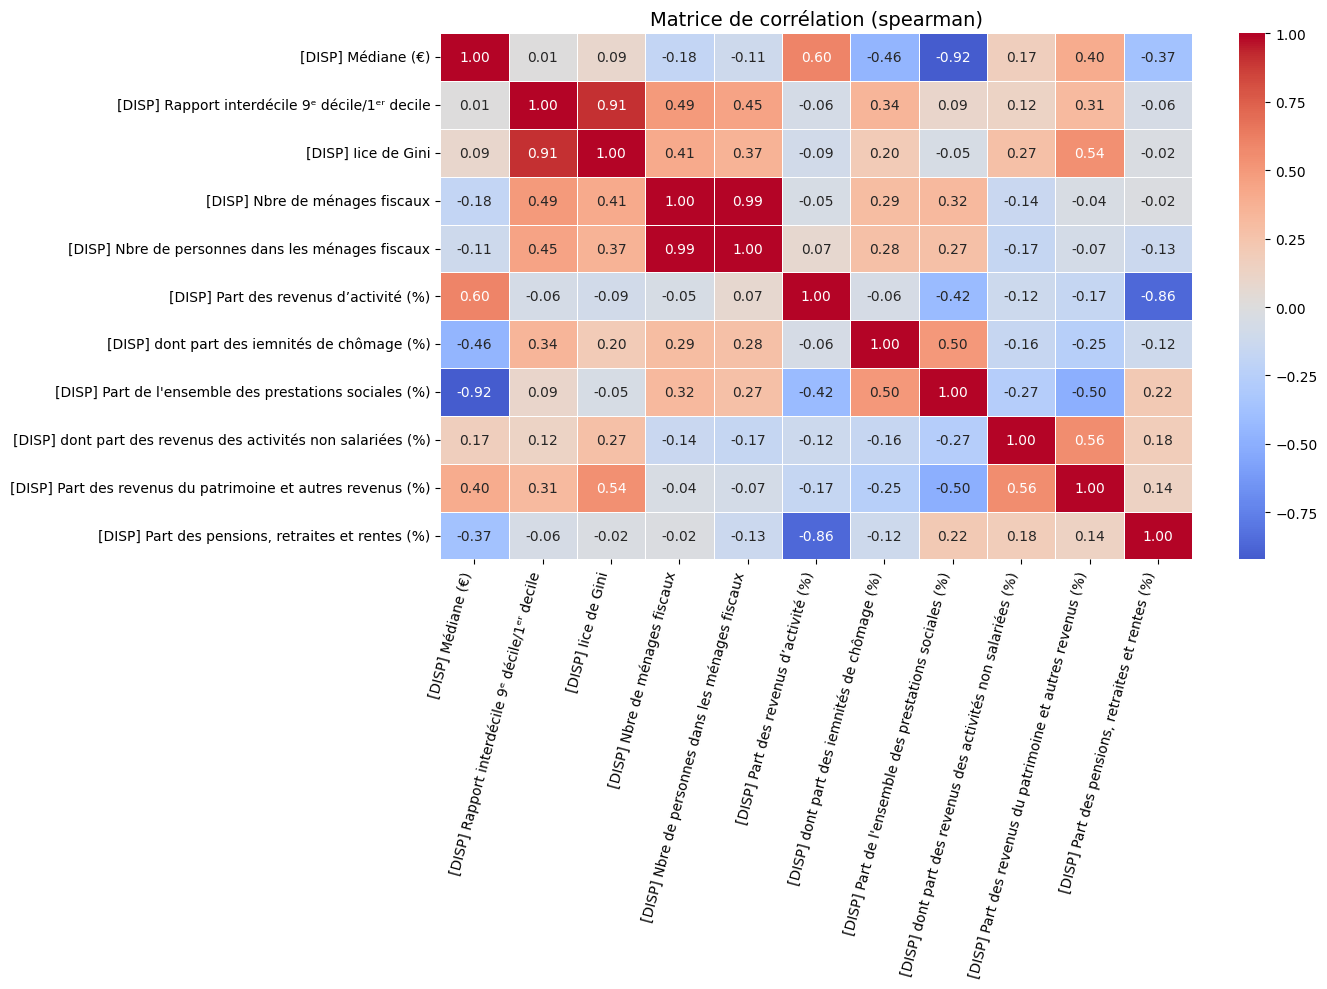

! Forte corrélation : [DISP] Iice de Gini <--> [DISP] Rapport interdécile 9ᵉ décile/1ᵉʳ decile (0.91)
! Forte corrélation : [DISP] Nbre de personnes dans les ménages fiscaux <--> [DISP] Nbre de ménages fiscaux (0.99)
! Forte corrélation : [DISP] Part de l'ensemble des prestations sociales (%) <--> [DISP] Médiane (€) (-0.92)
! Forte corrélation : [DISP] Part des pensions, retraites et rentes (%) <--> [DISP] Part des revenus d’activité (%) (-0.86)


In [11]:
from src.utils import afficher_matrice_correlation, identifier_fortes_correlations

# Affichage de la heatmap
matrix = afficher_matrice_correlation(df_filtre)

# Identification des doublons statistiques
paires = identifier_fortes_correlations(matrix, threshold=0.70)
for p in paires:
    print(f"! Forte corrélation : {p['v1']} <--> {p['v2']} ({p['val']:.2f})")


In [13]:
# Sélection finale validée pour le pipeline de préparation
var_finale_revenu = [
    'Code géographique',
    '[DISP] Médiane (€)',
    '[DISP] Iice de Gini',
    '[DISP] Nbre de ménages fiscaux',
    '[DISP] Nbre de personnes dans les ménages fiscaux',
    '[DISP] Part des revenus d’activité (%)',
    '[DISP] dont part des revenus des activités non salariées (%)',
    '[DISP] Part des revenus du patrimoine et autres revenus (%)'
]

df_revenu_final = df_filtre[var_finale_revenu]

L'analyse de corrélation a montré une colinéarité quasi parfaite ($r \approx 0.99$) entre le nombre de ménages et le nombre de personnes.

Nous décidons pour le moment de garder '[DISP] Nbre de ménages fiscaux' et '[DISP] Nbre de personnes dans les ménages fiscaux' car elles pourraient servir à normaliser de nouvelles variables (ex: indicateurs par habitant ou par foyer). Cependant, nous nous séparerons probablement de l'une des deux lors de la phase finale de modélisation pour éviter de biaiser les coefficients du modèle.

# brouillon

3. Indice de précarité
chomage + minima_sociaux + prestations_sociales
(normalisé)

à créer :
Ratio actifs / retraités
part_activite / part_retraites
👉 dynamisme démographique.